In [1]:
pip install jupyterlab-git

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf

In [3]:
tickers = ["GDX", "GOAU"]
prices = yf.download(tickers, start="2017-01-01", end="2023-01-01").dropna()

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed

In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'GDX Vs Gold futures')

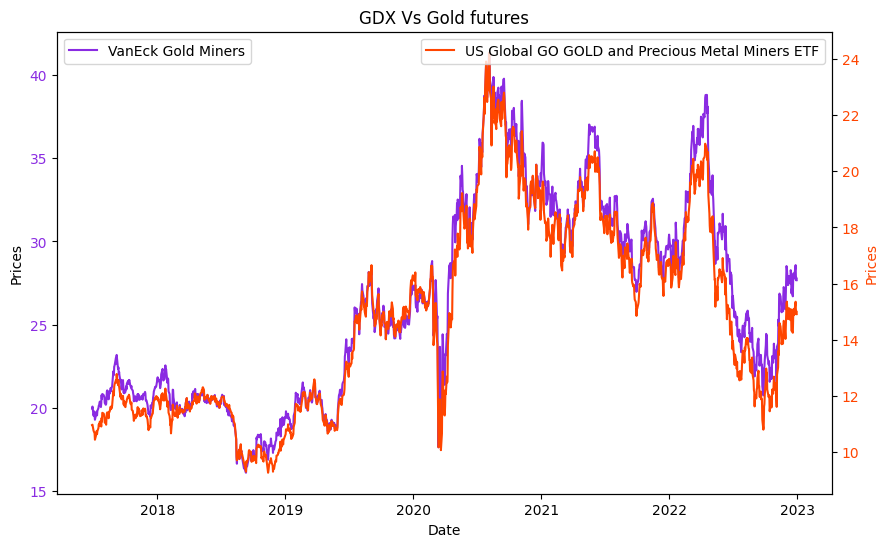

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(prices['Close']['GDX'], color='blueviolet', label='VanEck Gold Miners')
ax1.set_xlabel("Date")
ax1.set_ylabel("Prices")
ax1.tick_params(axis='y', labelcolor='blueviolet')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()

ax2.plot(prices['Close']['GOAU'], color='orangered', label='US Global GO GOLD and Precious Metal Miners ETF')
ax2.set_ylabel("Prices", color='orangered')
ax2.tick_params(axis='y', labelcolor='orangered')
ax2.legend(loc='upper right')

plt.title("GDX Vs Gold futures")

In [7]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [8]:
from statsmodels.api import add_constant

In [9]:
from statsmodels.api import OLS

In [10]:
X = add_constant(prices['Close']['GOAU'])
y = prices['Close']['GDX']

In [11]:
model = OLS(endog = y, exog = X)
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GDX   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                 7.027e+04
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:06:34   Log-Likelihood:                -1737.3
No. Observations:                1387   AIC:                             3479.
Df Residuals:                    1385   BIC:                             3489.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7623      0.099      7.694      0.000       0.568       0.957
GOAU           1.7277      0.007    265.084      0.000       1.715       1.741
==============================================================================
Omnibus:                       68.976   Durbin-Watson:                   0.074
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               71.107
Skew:                           0.520   Prob(JB):                     3.62e-16
Kurtosis:                       2.615   Cond. No.                         66.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
from statsmodels.tsa.stattools import adfuller

In [13]:
epsilon = res.resid
adf = adfuller(epsilon, autolag = 'AIC', regression = 'c')

In [14]:
print(f'ADF statistic : {adf[0]}')
print(f'ADF p_value : {adf[1]}')

ADF statistic : -3.7070641310404553
ADF p_value : 0.004014880908254286


In [15]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [16]:
import numpy as np

Text(0, 0.5, 'epsilon')

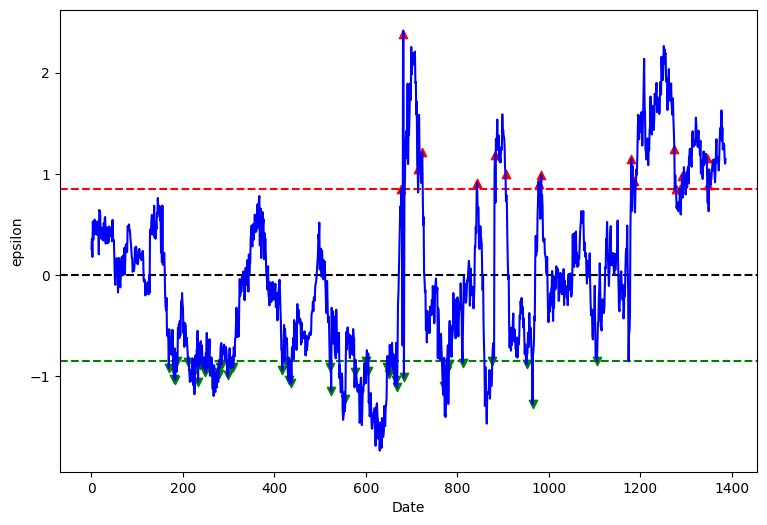

In [17]:
np_epsilon = np.array(epsilon)

mean_epsilon = np.mean(np_epsilon)
std_epsilon  = np.std(np_epsilon)

plt.figure(figsize=(9, 6))

plt.axhline(mean_epsilon,                color='black', linestyle='dashed')
plt.axhline(mean_epsilon + std_epsilon,  color='red',   linestyle='dashed')
plt.axhline(mean_epsilon - std_epsilon,  color='green', linestyle='dashed')

above = np.where(np_epsilon > mean_epsilon + std_epsilon)
below = np.where(np_epsilon < mean_epsilon - std_epsilon)

below = (below[0][:-1])[(below[0][:-1] + 1) != below[0][1:]]
above = (above[0][:-1])[(above[0][:-1] + 1) != above[0][1:]]

plt.scatter(above, np_epsilon[above], color='red',   marker='^')
plt.scatter(below, np_epsilon[below], color='green', marker='v')

plt.plot(np_epsilon, color='blue')
plt.xlabel('Date')
plt.ylabel('epsilon')

In [18]:
import scipy as sp

In [19]:
data = yf.download(tickers, start="2017-01-01", end="2023-01-01")['Close']
returns = data.pct_change().dropna()
hedge_ratio = sp.stats.pearsonr(returns['GDX'], returns['GOAU'])[0] * np.std(returns['GDX']) / np.std(returns['GOAU'])

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed

In [20]:
print(hedge_ratio)

0.9698572632107464


In [21]:
portfolio_ret = returns['GDX'] - hedge_ratio*returns['GOAU']
portfolio_cumret = np.cumsum(portfolio_ret)

Text(0, 0.5, 'rendements cumulés')

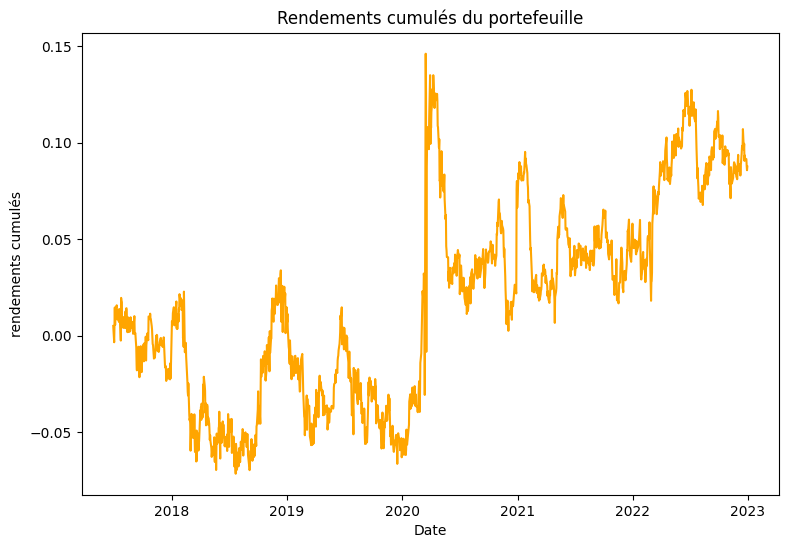

In [22]:
plt.figure(figsize=(9,6))
plt.plot(portfolio_cumret, color = 'orange')
plt.title('Rendements cumulés du portefeuille')
plt.xlabel('Date')
plt.ylabel('rendements cumulés')